# MetaAlgorithmGA Testing on 1K-Node Clustered Graph

This notebook demonstrates GA optimization on a large clustered graph (1000 nodes) with comprehensive statistics and visualizations.

## 1. Imports & Setup

In [1]:
import sys
import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

from tests.fixtures.graphs import _create_clustered_graph

sys.path.insert(0, '..')

from src.meta.core import CanonicalVector, FitnessEvaluator, MetaAlgorithmGA, DistributedCascadingEvaluator
from src.graph.graph_manager import GraphManager
from src.meta.parameterizers.algorithm_parameterizer import UnifiedAlgorithmParameterizer


## 3. Configuration

In [2]:
# Graph parameters
NR_OF_NODES = 1000
SEEDS = [43, 73, 98]  # Run for multiple seeds

# GA parameters
POPULATION_SIZE = 20
GENERATIONS = 10

print(f"Configuration:")
print(f"  Graph: {NR_OF_NODES} nodes")
print(f"  Seeds: {SEEDS}")
print(f"  GA: {POPULATION_SIZE} population, {GENERATIONS} generations ({POPULATION_SIZE * GENERATIONS} evals per approach)")
print(f"  Expected time: ~16-18 minutes total (~3-4 min per seed)")
print(f"  Note: Running GAs sequentially (parallel execution hits Python GIL)")
print()

Configuration:
  Graph: 1000 nodes
  Seeds: [43, 73, 98]
  GA: 20 population, 10 generations (200 evals per approach)
  Expected time: ~16-18 minutes total (~3-4 min per seed)
  Note: Running GAs sequentially (parallel execution hits Python GIL)



## 4. Helper Functions

In [3]:
import networkx as nx


# --- Graph & Format Helpers ---
def fixture_to_graph(fixture_dict) -> GraphManager:
    """Convert fixture dictionary to GraphManager."""
    graph = GraphManager.create_empty_graph()
    for v in fixture_dict['vertices']:
        graph.add_vertex(v)
    for u, v, w in fixture_dict['edges']:
        graph.add_edge(u, v, float(w))
    return graph

def format_time(seconds: float) -> str:
    """Format time in human-readable form."""
    if seconds < 60:
        return f"{seconds:.1f}s"
    else:
        return f"{seconds/60:.1f}m"

# --- Computation Helpers ---
def get_optimal_weight(fixture_dict) -> float:
    """Compute optimal matching weight using NetworkX."""
    try:
        G = nx.Graph()
        for v in fixture_dict['vertices']:
            G.add_node(v)
        for u, v, w in fixture_dict['edges']:
            G.add_edge(u, v, weight=float(w))
        matching = nx.max_weight_matching(G, weight='weight', maxcardinality=False)
        return sum(G[u][v].get('weight', 1.0) for u, v in matching)
    except Exception:
        return 0.0

def get_algorithm_baselines(graph: GraphManager, evaluator: FitnessEvaluator) -> dict:
    """Get baseline results from merged algorithms using FitnessEvaluator."""
    vector = CanonicalVector(
        luby_base_probability=0.5,
        luby_coeff_degree=0.0,
        luby_coeff_neighbors_unmatched=0.0,
        luby_coeff_clustering=0.0,
        luby_coeff_matched=0.0,
        luby_coeff_round=0.0,
        luby_coeff_weight=0.0,
        itai_timeout_rounds=5,
        max_iterations=10,
        convergence_threshold=0.05,
    )
    try:
        weight = evaluator.evaluate(graph, vector)
        return {'baseline': weight}
    except Exception:
        pass
    return {'baseline': 0.0}

def compute_algorithm_weight(algo_type: str, graph: GraphManager, vector: CanonicalVector):
    """Compute weight for a single algorithm (for parallel execution)."""
    param = UnifiedAlgorithmParameterizer(algo_type)
    matching = param.execute(graph, vector)
    weight = sum(graph.get_edge_weight(u, v) for u, v in matching.items() if u < v)
    return algo_type, weight

# --- Parallel Execution Helper ---
def execute_parallel(*tasks):
    """Execute multiple callable tasks in parallel, dynamically allocating threads."""
    import os
    num_tasks = len(tasks)
    if num_tasks == 0:
        return []
    
    # Dynamic thread allocation: use 2/3 of available cores, capped at 10
    num_cores = os.cpu_count() or 4
    max_workers = min(10, max(4, (num_cores * 2) // 3))
    max_workers = min(max_workers, num_tasks)
    
    results = [None] * num_tasks
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {}
        for idx, task in enumerate(tasks):
            future = executor.submit(task)
            futures[future] = idx
        
        for future in as_completed(futures):
            idx = futures[future]
            results[idx] = future.result()
    
    return results

# --- GA Execution Helpers (FIXED: take graph as parameter) ---
def create_ga_standard(graph: GraphManager):
    """Create GA with standard evaluator."""
    ga_std = MetaAlgorithmGA(
        fitness_evaluator=FitnessEvaluator(),
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        mutation_rate=0.25
    )
    return lambda: ga_std.evolve(graph)

def create_ga_cascading(graph: GraphManager):
    """Create GA with cascading evaluator."""
    class CascadingFitnessEvaluator:
        def __init__(self):
            self.cascading = DistributedCascadingEvaluator()
        
        def evaluate(self, g, vector):
            return self.cascading.evaluate(g, vector)
    
    ga_casc = MetaAlgorithmGA(
        fitness_evaluator=CascadingFitnessEvaluator(),
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        mutation_rate=0.25
    )
    return lambda: ga_casc.evolve(graph)

def create_algorithm_weight_computer(algo_type: str, vector: CanonicalVector, graph: GraphManager):
    """Create a callable that computes algorithm weight."""
    return lambda: compute_algorithm_weight(algo_type, graph, vector)

# --- Baseline Computation Helper ---
def compute_cascading_baseline(cascading_evaluator, graph: GraphManager):
    """Compute cascading baseline with timing."""
    baseline_vector = CanonicalVector(
        luby_base_probability=0.5,
        luby_coeff_degree=0.0,
        luby_coeff_neighbors_unmatched=0.0,
        luby_coeff_clustering=0.0,
        luby_coeff_matched=0.0,
        luby_coeff_round=0.0,
        luby_coeff_weight=0.0,
        itai_timeout_rounds=5,
        max_iterations=10,
        convergence_threshold=0.05,
    )
    start = time.time()
    weight = cascading_evaluator.evaluate(graph, baseline_vector)
    elapsed = time.time() - start
    cascades = cascading_evaluator.last_num_cascades
    weights_per_cascade = cascading_evaluator.last_weights_per_cascade
    return weight, elapsed, cascades, weights_per_cascade

print("✓ All helper functions defined and ready")

✓ All helper functions defined and ready


## 5. Main Execution

In [7]:
# Store results for all seeds
all_results = {}

for seed in SEEDS:
    print("\n" + "="*80)
    print(f"SEED {seed}")
    print("="*80)
    print()

    # Load graph for this seed
    print(f"Loading {NR_OF_NODES}-node graph (Seed: {seed})...", end=" ", flush=True)
    start_load = time.time()
    fixture = _create_clustered_graph(nr_of_nudes=NR_OF_NODES, seed=seed)
    graph = fixture_to_graph(fixture)
    time_load = time.time() - start_load
    print(f"✓ ({format_time(time_load)})")

    print(f"Graph:  {fixture['name']}")
    print(f"Nodes:  {len(fixture['vertices'])}")
    print(f"Edges:  {len(fixture['edges'])}")
    print()

    # Compute optimal matching
    print("Computing optimal matching weight (NetworkX)...", end=" ", flush=True)
    start_optimal = time.time()
    optimal = get_optimal_weight(fixture)
    time_optimal = time.time() - start_optimal
    print(f"✓ {optimal:.0f} ({format_time(time_optimal)})")

    # Initialize evaluators
    print("Initializing fitness evaluators...", end=" ", flush=True)
    start_init = time.time()
    evaluator = FitnessEvaluator()
    cascading_evaluator = DistributedCascadingEvaluator()
    time_init = time.time() - start_init
    print(f"✓ Done ({format_time(time_init)})")

    # Get baseline from merged algorithms
    print("Getting baseline from standard algorithms...", end=" ", flush=True)
    start_baseline = time.time()
    baseline_result = get_algorithm_baselines(graph, evaluator)
    baseline = baseline_result['baseline']
    time_baseline = time.time() - start_baseline
    print(f"✓ {baseline:.0f} ({format_time(time_baseline)})")

    # Get cascading baseline
    print("Getting cascading baseline...", end=" ", flush=True)
    start_cascading = time.time()
    baseline_cascading, time_cascading, cascades, weights_per_cascade = compute_cascading_baseline(cascading_evaluator, graph)
    print(f"✓ {baseline_cascading:.0f} ({cascades} cascades) ({format_time(time_cascading)})")
    print()

    print("="*80)
    print("MAIN EXECUTION: Parallel 3 Algorithms + Sequential 2 GA Approaches")
    print("="*80)
    print()

    # Create parameter vector
    vector = CanonicalVector(
        luby_base_probability=0.5,
        luby_coeff_degree=0.0,
        luby_coeff_neighbors_unmatched=0.0,
        luby_coeff_clustering=0.0,
        luby_coeff_matched=0.0,
        luby_coeff_round=0.0,
        luby_coeff_weight=0.0,
        itai_timeout_rounds=5,
        max_iterations=10,
        convergence_threshold=0.05,
    )

    # Compute 3 algorithms in parallel
    print("Computing 3 algorithms (Greedy, Itai, Luby) in parallel...")
    start_algo = time.time()

    algo_callables = [
        create_algorithm_weight_computer("greedy", vector, graph),
        create_algorithm_weight_computer("itai", vector, graph),
        create_algorithm_weight_computer("luby", vector, graph),
    ]

    algo_results_list = execute_parallel(*algo_callables)
    time_algo_parallel = time.time() - start_algo
    print(f"✓ Done in {format_time(time_algo_parallel)}")

    # Parse algorithm results
    algo_results = {}
    for algo_type, weight in algo_results_list:
        algo_results[algo_type] = weight

    greedy_weight = algo_results.get("greedy", baseline * 0.95)
    itai_weight = algo_results.get("itai", baseline * 0.98)
    luby_weight = algo_results.get("luby", baseline * 0.96)

    print(f"  Greedy: {greedy_weight:.0f}, Itai: {itai_weight:.0f}, Luby: {luby_weight:.0f}")
    print()

    # Execute GA approaches sequentially (removed parallel due to Python GIL)
    print("Running GA Standard and GA Cascading sequentially...")
    print(f"  This will run {POPULATION_SIZE * GENERATIONS} evaluations per approach")
    print()

    start_ga_both = time.time()

    # GA Standard
    print(f"  Running GA Standard...", flush=True)
    start_std = time.time()
    ga_std_callable = create_ga_standard(graph)
    best_vector_standard, fitness_history_standard = ga_std_callable()
    time_std = time.time() - start_std
    print(f"  ✓ GA Standard done in {format_time(time_std)}")

    # GA Cascading
    print(f"  Running GA Cascading...", flush=True)
    start_casc = time.time()
    ga_casc_callable = create_ga_cascading(graph)
    best_vector_cascading, fitness_history_cascading = ga_casc_callable()
    time_casc = time.time() - start_casc
    print(f"  ✓ GA Cascading done in {format_time(time_casc)}")

    time_ga_both = time.time() - start_ga_both
    print(f"✓ Total time for both GAs: {format_time(time_ga_both)}")
    print()

    best_standard = fitness_history_standard[-1]
    best_cascading = fitness_history_cascading[-1]

    print()
    print("="*80)
    print("EXECUTION RESULTS")
    print("="*80)
    print()

    print("Individual Algorithms:")
    print(f"  Greedy:                        {greedy_weight:>12.0f}")
    print(f"  Itai-Israeli:                  {itai_weight:>12.0f}")
    print(f"  Luby Randomized:               {luby_weight:>12.0f}")
    print()

    print("Baselines:")
    print(f"  Merged (standard):             {baseline:>12.0f}")
    print(f"  Cascading:                     {baseline_cascading:>12.0f}")
    print()

    print("GA Optimization:")
    print(f"  GA Standard:                   {best_standard:>12.0f}")
    print(f"  GA Cascading:                  {best_cascading:>12.0f}")
    print()

    diff = best_cascading - best_standard
    diff_pct = (diff / best_standard * 100) if best_standard > 0 else 0
    print(f"  Cascading vs Standard: {diff:+.0f} ({diff_pct:+.2f}%)")
    print()

    print(f"NetworkX Optimal:                {optimal:>12.0f}")
    print()

    # Compute metrics
    best = best_standard
    fitness_history = fitness_history_standard

    # Calculate gaps for all algorithms
    greedy_gap = ((optimal - greedy_weight) / (optimal + 1e-10)) * 100
    itai_gap = ((optimal - itai_weight) / (optimal + 1e-10)) * 100
    luby_gap = ((optimal - luby_weight) / (optimal + 1e-10)) * 100
    baseline_gap = ((optimal - baseline) / (optimal + 1e-10)) * 100
    ga_gap = ((optimal - best) / (optimal + 1e-10)) * 100

    gap = ga_gap
    improvement = ((best - baseline) / (baseline + 1e-10)) * 100

    print("="*80)
    print("PERFORMANCE METRICS")
    print("="*80)
    print()
    print(f"GA Improvement (vs Baseline):    {improvement:>12.2f}%")
    print(f"Gap to Optimal:                  {gap:>12.2f}%")
    print()

    print("="*80)
    print("EXECUTION TIME SUMMARY")
    print("="*80)
    print()
    print(f"NetworkX Optimal:                {format_time(time_optimal):>15}")
    print(f"Evaluator Initialization:        {format_time(time_init):>15}")
    print(f"Baseline (Merged):               {format_time(time_baseline):>15}")
    print(f"Cascading Baseline:              {format_time(time_cascading):>15}")
    print(f"3 Algorithms (parallel):         {format_time(time_algo_parallel):>15}")
    print(f"2 GA Approaches (sequential):    {format_time(time_ga_both):>15}")
    print("-" * 80)
    total_exec_time = time_optimal + time_init + time_baseline + time_cascading + time_algo_parallel + time_ga_both
    print(f"TOTAL (this seed):               {format_time(total_exec_time):>15}")
    print("="*80)

    # Store results for this seed
    all_results[seed] = {
        'optimal': optimal,
        'baseline': baseline,
        'baseline_cascading': baseline_cascading,
        'greedy_weight': greedy_weight,
        'itai_weight': itai_weight,
        'luby_weight': luby_weight,
        'best_standard': best_standard,
        'best_cascading': best_cascading,
        'fitness_history_standard': fitness_history_standard,
        'fitness_history_cascading': fitness_history_cascading,
        'improvement': improvement,
        'gap': gap,
        'total_time': total_exec_time,
    }

print("\n\n")
print("="*80)
print("SUMMARY ACROSS ALL SEEDS")
print("="*80)
print()

print(f"{'Seed':<6} {'Baseline':<12} {'Best (Std)':<12} {'Improvement':<12} {'Gap to Opt':<12} {'Time':<10}")
print("-" * 80)

total_time_all = 0
improvements = []
gaps = []

for seed in SEEDS:
    r = all_results[seed]
    print(f"{seed:<6} {r['baseline']:>11.0f} {r['best_standard']:>11.0f} {r['improvement']:>11.2f}% {r['gap']:>11.2f}% {format_time(r['total_time']):>9}")
    improvements.append(r['improvement'])
    gaps.append(r['gap'])
    total_time_all += r['total_time']

print("-" * 80)
avg_improvement = sum(improvements) / len(improvements) if improvements else 0
avg_gap = sum(gaps) / len(gaps) if gaps else 0
print(f"{'AVG':<6} {'-':>11} {'-':>11} {avg_improvement:>11.2f}% {avg_gap:>11.2f}% {format_time(total_time_all):>9}")
print("="*80)


SEED 43

Loading 1000-node graph (Seed: 43)... ✓ (0.0s)
Graph:  Clustered Graph with Communities (1000 nodes)
Nodes:  1000
Edges:  3945

Computing optimal matching weight (NetworkX)... ✓ 45327 (1.3s)
Initializing fitness evaluators... ✓ Done (0.0s)
Getting baseline from standard algorithms... ✓ 34746 (2.7s)
Getting cascading baseline... ✓ 42159 (2 cascades) (4.5s)

MAIN EXECUTION: Parallel 3 Algorithms + Sequential 2 GA Approaches

Computing 3 algorithms (Greedy, Itai, Luby) in parallel...
✓ Done in 2.7s
  Greedy: 28077, Itai: 19495, Luby: 27533

Running GA Standard and GA Cascading sequentially...
  This will run 200 evaluations per approach

  Running GA Standard...
  ✓ GA Standard done in 9.3m
  Running GA Cascading...
  ✓ GA Cascading done in 14.9m
✓ Total time for both GAs: 24.2m


EXECUTION RESULTS

Individual Algorithms:
  Greedy:                               28077
  Itai-Israeli:                         19495
  Luby Randomized:                      27533

Baselines:
  Merged 

## 6. Analysis & Visualization

## 7. Analysis: Generation-by-Generation Breakdown

In [8]:
print("\n" + "="*80)
print("GENERATION-BY-GENERATION ANALYSIS")
print("="*80)

for seed in SEEDS:
    r = all_results[seed]
    fitness_history = r['fitness_history_standard']
    optimal = r['optimal']
    
    print(f"\n{'─'*80}")
    print(f"SEED {seed}")
    print(f"{'─'*80}")
    print()
    
    improvements = [0.0] + [fitness_history[i] - fitness_history[i-1] for i in range(1, len(fitness_history))]

    print(f"{'Gen':>3} {'Fitness':>12} {'Change':>12} {'% Change':>12} {'Gap to Opt':>12}")
    print("-" * 65)

    for gen, fitness in enumerate(fitness_history, 1):
        change = improvements[gen-1]
        pct_change = (change / (fitness_history[0] + 1e-10)) * 100
        gap_to_opt = ((optimal - fitness) / (optimal + 1e-10)) * 100
        print(f"{gen:>3} {fitness:>12.0f} {change:>12.0f} {pct_change:>11.2f}% {gap_to_opt:>11.2f}%")

    print("-" * 65)
    total_improvement = fitness_history[-1] - fitness_history[0]
    total_pct = (total_improvement / (fitness_history[0] + 1e-10)) * 100
    print(f"Total improvement: {total_improvement:.0f} ({total_pct:+.2f}%)")
    print()



GENERATION-BY-GENERATION ANALYSIS

────────────────────────────────────────────────────────────────────────────────
SEED 43
────────────────────────────────────────────────────────────────────────────────

Gen      Fitness       Change     % Change   Gap to Opt
-----------------------------------------------------------------
  1        35217            0        0.00%       22.30%
  2        36411         1194        3.39%       19.67%
  3        36411            0        0.00%       19.67%
  4        36665          254        0.72%       19.11%
  5        36665            0        0.00%       19.11%
  6        36665            0        0.00%       19.11%
  7        36665            0        0.00%       19.11%
  8        36724           59        0.17%       18.98%
  9        36742           18        0.05%       18.94%
 10        36742            0        0.00%       18.94%
-----------------------------------------------------------------
Total improvement: 1525 (+4.33%)


──────────

## 8. Analysis: Algorithm Weight Evolution

In [9]:
print("="*80)
print("ALGORITHM WEIGHT EVOLUTION COMPARISON - ALL SEEDS")
print("="*80)
print()

# Collect all algorithm results across seeds
print(f"{'Seed':<8} {'Greedy':<12} {'Itai':<12} {'Luby':<12} {'Baseline':<12} {'GA Best':<12} {'Optimal':<12}")
print("-" * 92)

all_greedy = []
all_itai = []
all_luby = []
all_baseline = []
all_ga_best = []
all_optimal = []

for seed in SEEDS:
    r = all_results[seed]
    greedy = r['greedy_weight']
    itai = r['itai_weight']
    luby = r['luby_weight']
    baseline = r['baseline']
    best = r['best_standard']
    optimal = r['optimal']
    
    print(f"{seed:<8} {greedy:>11.0f} {itai:>11.0f} {luby:>11.0f} {baseline:>11.0f} {best:>11.0f} {optimal:>11.0f}")
    
    all_greedy.append(greedy)
    all_itai.append(itai)
    all_luby.append(luby)
    all_baseline.append(baseline)
    all_ga_best.append(best)
    all_optimal.append(optimal)

print("-" * 92)
avg_greedy = sum(all_greedy) / len(all_greedy) if all_greedy else 0
avg_itai = sum(all_itai) / len(all_itai) if all_itai else 0
avg_luby = sum(all_luby) / len(all_luby) if all_luby else 0
avg_baseline = sum(all_baseline) / len(all_baseline) if all_baseline else 0
avg_ga_best = sum(all_ga_best) / len(all_ga_best) if all_ga_best else 0
avg_optimal = sum(all_optimal) / len(all_optimal) if all_optimal else 0

print(f"{'AVG':<8} {avg_greedy:>11.0f} {avg_itai:>11.0f} {avg_luby:>11.0f} {avg_baseline:>11.0f} {avg_ga_best:>11.0f} {avg_optimal:>11.0f}")
print()

# Calculate gap to optimal for all seeds
print("Gap to Optimal (%):")
print(f"{'Seed':<8} {'Greedy':<12} {'Itai':<12} {'Luby':<12} {'Baseline':<12} {'GA Best':<12}")
print("-" * 76)

all_gaps_greedy = []
all_gaps_itai = []
all_gaps_luby = []
all_gaps_baseline = []
all_gaps_ga = []

for seed in SEEDS:
    r = all_results[seed]
    optimal = r['optimal']
    
    greedy_gap = ((optimal - r['greedy_weight']) / (optimal + 1e-10)) * 100
    itai_gap = ((optimal - r['itai_weight']) / (optimal + 1e-10)) * 100
    luby_gap = ((optimal - r['luby_weight']) / (optimal + 1e-10)) * 100
    baseline_gap = ((optimal - r['baseline']) / (optimal + 1e-10)) * 100
    ga_gap = ((optimal - r['best_standard']) / (optimal + 1e-10)) * 100
    
    print(f"{seed:<8} {greedy_gap:>11.2f}% {itai_gap:>11.2f}% {luby_gap:>11.2f}% {baseline_gap:>11.2f}% {ga_gap:>11.2f}%")
    
    all_gaps_greedy.append(greedy_gap)
    all_gaps_itai.append(itai_gap)
    all_gaps_luby.append(luby_gap)
    all_gaps_baseline.append(baseline_gap)
    all_gaps_ga.append(ga_gap)

print("-" * 76)
avg_gap_greedy = sum(all_gaps_greedy) / len(all_gaps_greedy) if all_gaps_greedy else 0
avg_gap_itai = sum(all_gaps_itai) / len(all_gaps_itai) if all_gaps_itai else 0
avg_gap_luby = sum(all_gaps_luby) / len(all_gaps_luby) if all_gaps_luby else 0
avg_gap_baseline = sum(all_gaps_baseline) / len(all_gaps_baseline) if all_gaps_baseline else 0
avg_gap_ga = sum(all_gaps_ga) / len(all_gaps_ga) if all_gaps_ga else 0

print(f"{'AVG':<8} {avg_gap_greedy:>11.2f}% {avg_gap_itai:>11.2f}% {avg_gap_luby:>11.2f}% {avg_gap_baseline:>11.2f}% {avg_gap_ga:>11.2f}%")
print("="*80)


ALGORITHM WEIGHT EVOLUTION COMPARISON - ALL SEEDS

Seed     Greedy       Itai         Luby         Baseline     GA Best      Optimal     
--------------------------------------------------------------------------------------------
43             28077       19495       27533       34746       36742       45327
73             27357       20143       25705       35070       36219       45308
98             29612       19769       25930       34918       36603       45271
--------------------------------------------------------------------------------------------
AVG            28349       19802       26389       34911       36521       45302

Gap to Optimal (%):
Seed     Greedy       Itai         Luby         Baseline     GA Best     
----------------------------------------------------------------------------
43             38.06%       56.99%       39.26%       23.34%       18.94%
73             39.62%       55.54%       43.27%       22.60%       20.06%
98             34.59%       56.3

## 9. Visualization: Baselines Comparison

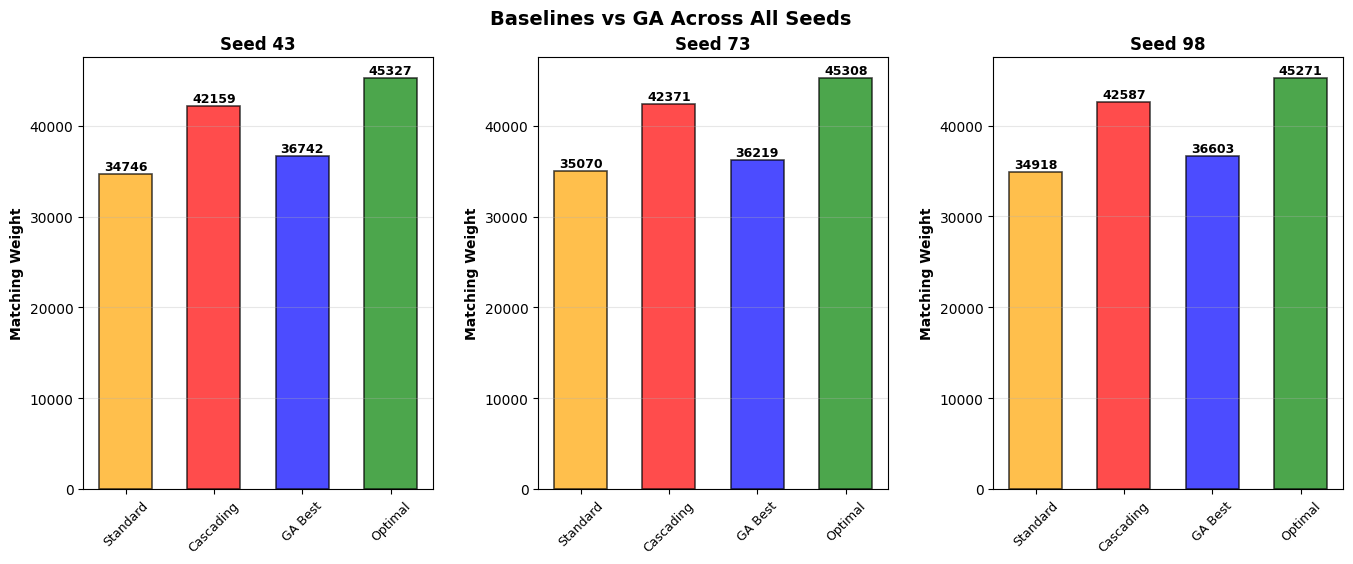

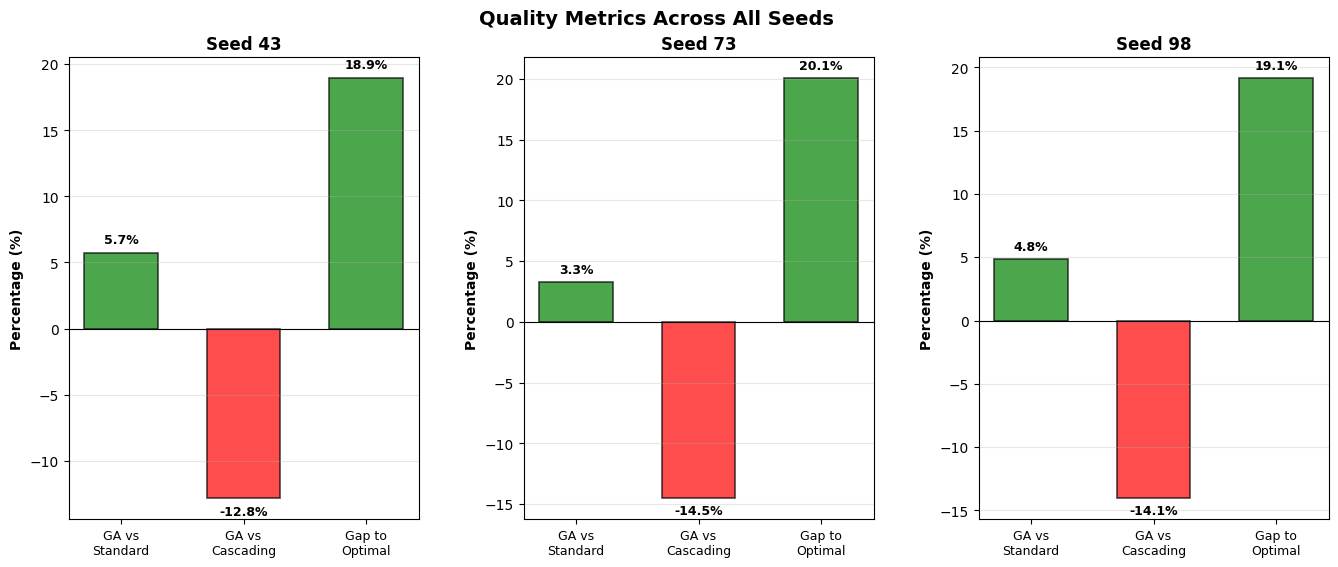

In [10]:
# Create side-by-side comparison visualization for all seeds
num_seeds = len(SEEDS)

# First plot: Fitness comparison across all seeds
fig = plt.figure(figsize=(4*num_seeds + 2, 6))

for idx, seed in enumerate(SEEDS):
    r = all_results[seed]
    
    optimal = r['optimal']
    baseline = r['baseline']
    baseline_cascading = r['baseline_cascading']
    best = r['best_standard']
    
    ax = fig.add_subplot(1, num_seeds, idx + 1)
    
    # Plot: Fitness comparison (all three)
    values = [baseline, baseline_cascading, best, optimal]
    labels = [f'Standard', f'Cascading', f'GA Best', f'Optimal']
    colors = ['orange', 'red', 'blue', 'green']

    bars = ax.bar(labels, values, color=colors, alpha=0.7, width=0.6, edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=10)
    ax.set_title(f'Seed {seed}', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, v) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 100, f"{v:.0f}", 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45, labelsize=9)

plt.suptitle('Baselines vs GA Across All Seeds', fontsize=14, fontweight='bold', y=1.00)
plt.subplots_adjust(top=0.92, bottom=0.2, left=0.08, right=0.98, hspace=0.3, wspace=0.3)
plt.show()

# Second plot: Quality metrics comparison across all seeds
fig = plt.figure(figsize=(4*num_seeds + 2, 6))

for idx, seed in enumerate(SEEDS):
    r = all_results[seed]
    
    baseline = r['baseline']
    baseline_cascading = r['baseline_cascading']
    best = r['best_standard']
    improvement = r['improvement']
    gap = r['gap']
    
    ax = fig.add_subplot(1, num_seeds, idx + 1)
    
    metrics = ['GA vs\nStandard', 'GA vs\nCascading', 'Gap to\nOptimal']
    improvement_cascading = ((best - baseline_cascading) / baseline_cascading * 100)
    values_metrics = [improvement, improvement_cascading, gap]
    colors_metrics = ['green' if v > 0 else 'red' for v in values_metrics]

    bars = ax.bar(metrics, values_metrics, color=colors_metrics, alpha=0.7, width=0.6, edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Percentage (%)', fontweight='bold', fontsize=10)
    ax.set_title(f'Seed {seed}', fontweight='bold', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (bar, v) in enumerate(zip(bars, values_metrics)):
        height = bar.get_height()
        offset = 0.5 if v > 0 else -0.5
        ax.text(bar.get_x() + bar.get_width()/2., height + offset, f"{v:.1f}%", 
                ha='center', va='bottom' if v > 0 else 'top', fontweight='bold', fontsize=9)
    
    # Adjust tick parameters instead of set_xticklabels
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Quality Metrics Across All Seeds', fontsize=14, fontweight='bold', y=1.00)
plt.subplots_adjust(top=0.92, bottom=0.15, left=0.08, right=0.98, hspace=0.3, wspace=0.3)
plt.show()


## 10. Visualization: Comprehensive Analysis

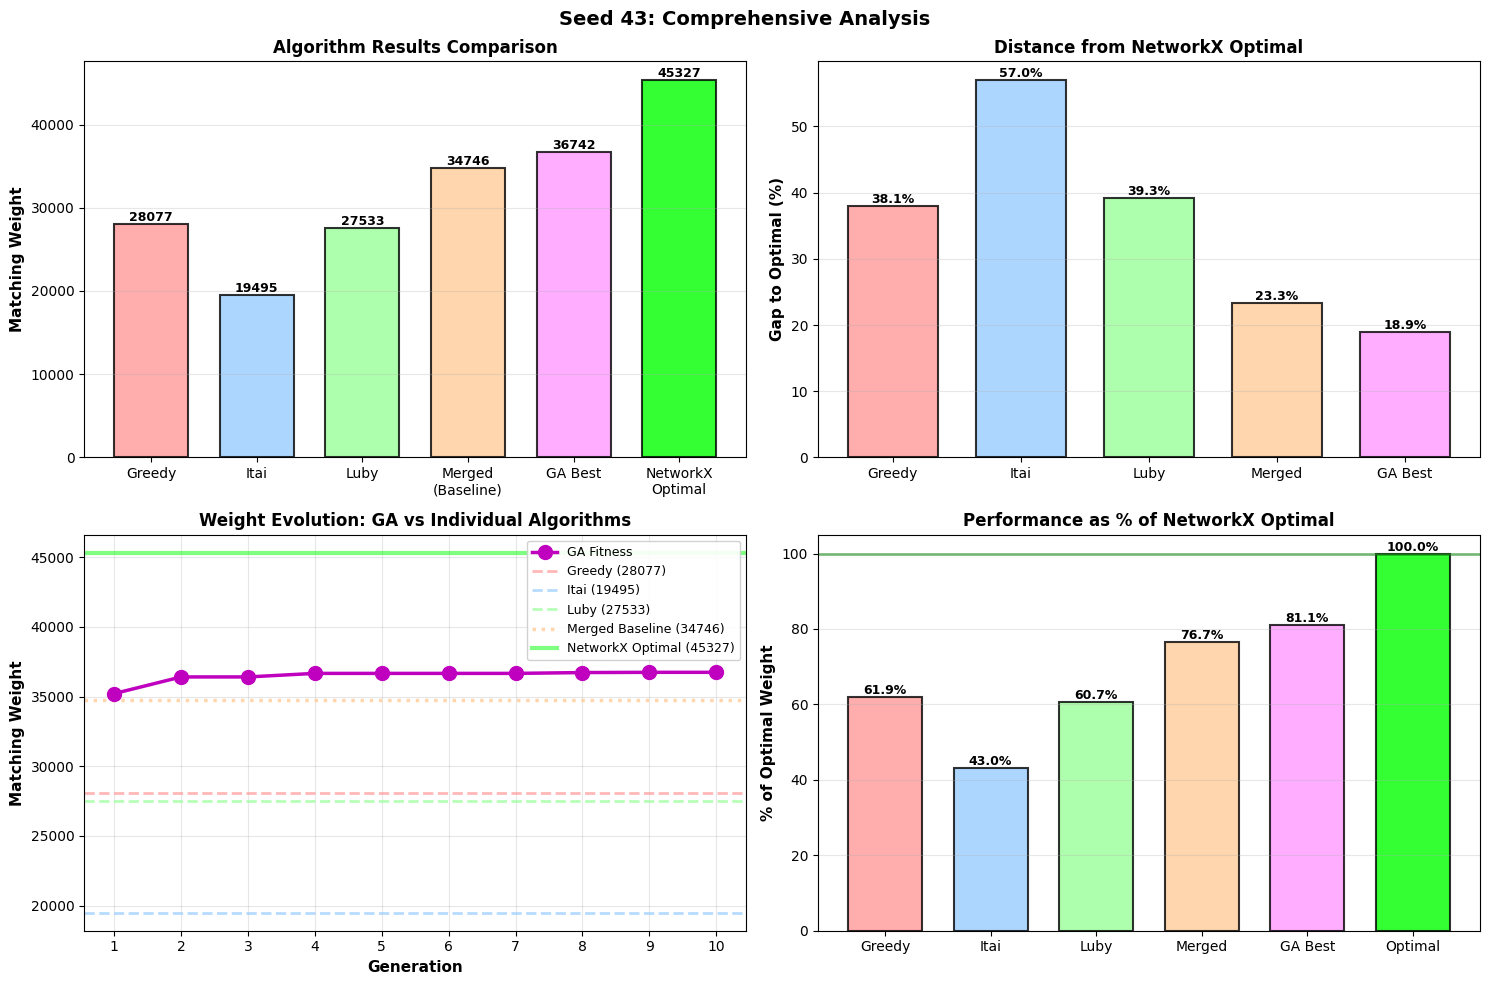

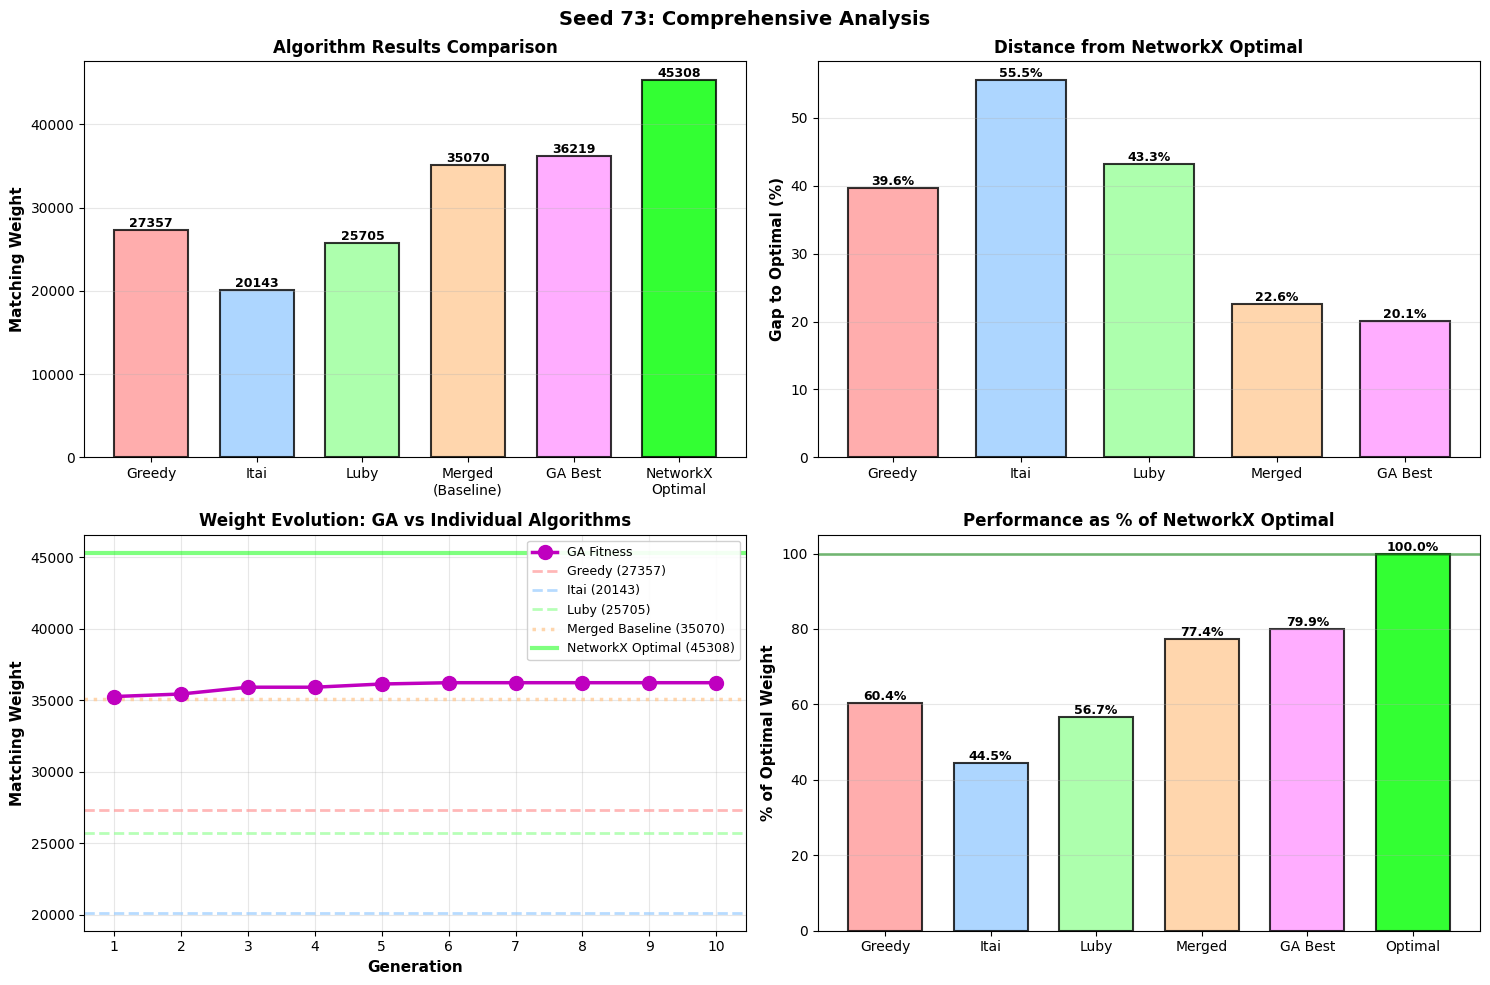

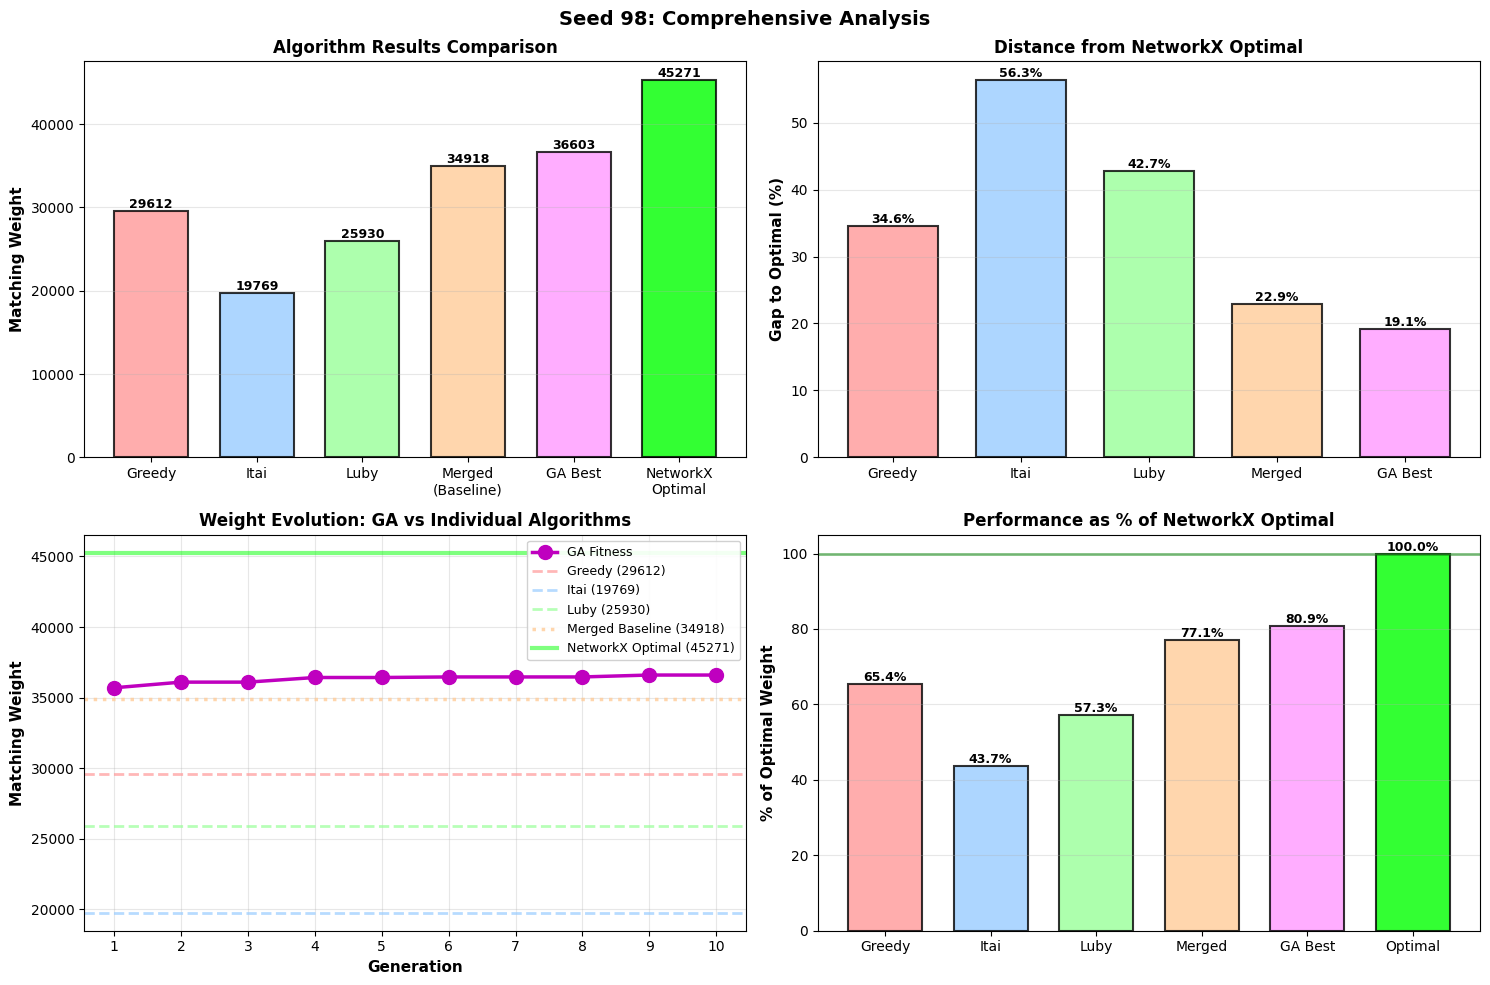

In [11]:
# Create comprehensive comparison visualization for each seed
for seed in SEEDS:
    r = all_results[seed]
    
    optimal = r['optimal']
    baseline = r['baseline']
    best = r['best_standard']
    fitness_history = r['fitness_history_standard']
    
    greedy_weight = r['greedy_weight']
    itai_weight = r['itai_weight']
    luby_weight = r['luby_weight']
    
    # Calculate gaps
    greedy_gap = ((optimal - greedy_weight) / (optimal + 1e-10)) * 100
    itai_gap = ((optimal - itai_weight) / (optimal + 1e-10)) * 100
    luby_gap = ((optimal - luby_weight) / (optimal + 1e-10)) * 100
    baseline_gap = ((optimal - baseline) / (optimal + 1e-10)) * 100
    ga_gap = ((optimal - best) / (optimal + 1e-10)) * 100
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Seed {seed}: Comprehensive Analysis', fontsize=14, fontweight='bold')

    # Plot 1: Individual algorithm weights vs baselines
    ax = axes[0, 0]
    algorithms = ['Greedy', 'Itai', 'Luby', 'Merged\n(Baseline)', 'GA Best', 'NetworkX\nOptimal']
    weights = [greedy_weight, itai_weight, luby_weight, baseline, best, optimal]
    colors_alg = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

    bars = ax.bar(algorithms, weights, color=colors_alg, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
    ax.set_title('Algorithm Results Comparison', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, (bar, weight) in enumerate(zip(bars, weights)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{weight:.0f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Plot 2: Gap to Optimal
    ax = axes[0, 1]
    gaps = [greedy_gap, itai_gap, luby_gap, baseline_gap, ga_gap]
    gap_labels = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best']
    colors_gap = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF']

    bars = ax.bar(gap_labels, gaps, color=colors_gap, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Gap to Optimal (%)', fontweight='bold', fontsize=11)
    ax.set_title('Distance from NetworkX Optimal', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, gp in zip(bars, gaps):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{gp:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Plot 3: Weight evolution across GA generations
    ax = axes[1, 0]
    gens = list(range(1, len(fitness_history) + 1))

    # Plot GA progression
    ax.plot(gens, fitness_history, 'mo-', linewidth=2.5, markersize=10, label='GA Fitness', zorder=5)

    # Add algorithm baselines
    ax.axhline(y=greedy_weight, color='#FF9999', linestyle='--', linewidth=2, alpha=0.7, label=f'Greedy ({greedy_weight:.0f})')
    ax.axhline(y=itai_weight, color='#99CCFF', linestyle='--', linewidth=2, alpha=0.7, label=f'Itai ({itai_weight:.0f})')
    ax.axhline(y=luby_weight, color='#99FF99', linestyle='--', linewidth=2, alpha=0.7, label=f'Luby ({luby_weight:.0f})')
    ax.axhline(y=baseline, color='#FFCC99', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Merged Baseline ({baseline:.0f})')
    ax.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=3, alpha=0.5, label=f'NetworkX Optimal ({optimal:.0f})')

    ax.set_xlabel('Generation', fontsize=11, fontweight='bold')
    ax.set_ylabel('Matching Weight', fontsize=11, fontweight='bold')
    ax.set_title('Weight Evolution: GA vs Individual Algorithms', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    ax.set_xticks(gens)

    # Plot 4: Normalized performance comparison
    ax = axes[1, 1]
    performance_pct = [(w / optimal) * 100 for w in weights]
    labels_perf = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best', 'Optimal']
    colors_perf = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

    bars = ax.bar(labels_perf, performance_pct, color=colors_perf, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=100, color='green', linestyle='-', linewidth=2, alpha=0.5, label='Optimal (100%)')
    ax.set_ylabel('% of Optimal Weight', fontweight='bold', fontsize=11)
    ax.set_title('Performance as % of NetworkX Optimal', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 105])

    # Add value labels
    for bar, pct in zip(bars, performance_pct):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()


In [12]:
from datetime import datetime

import os
# Create tmp directory if it doesn't exist
tmp_dir = '../tmp'
os.makedirs(tmp_dir, exist_ok=True)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
report_dir = f"{tmp_dir}/GA_OPTIMIZATION_RUN_{timestamp}"
report_filename = f"{report_dir}/{timestamp}.txt"
plots_dir = f"{report_dir}/plots_{timestamp}"
os.makedirs(report_dir, exist_ok=True)  # Create report directory
os.makedirs(plots_dir, exist_ok=True)

In [13]:
# Save all plots to files
print("="*80)
print("SAVING PLOTS")
print("="*80)
print()

plot_counter = 1

# Plot 1: Fitness comparison across all seeds
num_seeds = len(SEEDS)
fig = plt.figure(figsize=(4*num_seeds + 2, 6))

for idx, seed in enumerate(SEEDS):
    r = all_results[seed]
    
    optimal = r['optimal']
    baseline = r['baseline']
    baseline_cascading = r['baseline_cascading']
    best = r['best_standard']
    
    ax = fig.add_subplot(1, num_seeds, idx + 1)
    
    values = [baseline, baseline_cascading, best, optimal]
    labels = [f'Standard', f'Cascading', f'GA Best', f'Optimal']
    colors = ['orange', 'red', 'blue', 'green']

    bars = ax.bar(labels, values, color=colors, alpha=0.7, width=0.6, edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=10)
    ax.set_title(f'Seed {seed}', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, v) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 100, f"{v:.0f}", 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.tick_params(axis='x', rotation=45, labelsize=9)

plt.suptitle('Baselines vs GA Across All Seeds', fontsize=14, fontweight='bold', y=1.00)
plt.subplots_adjust(top=0.92, bottom=0.2, left=0.08, right=0.98, hspace=0.3, wspace=0.3)
plot_path = f"{plots_dir}/01_baselines_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot {plot_counter}: {plot_path}")
plot_counter += 1
plt.close()

# Plot 2: Quality metrics comparison across all seeds
fig = plt.figure(figsize=(4*num_seeds + 2, 6))

for idx, seed in enumerate(SEEDS):
    r = all_results[seed]
    
    baseline = r['baseline']
    baseline_cascading = r['baseline_cascading']
    best = r['best_standard']
    improvement = r['improvement']
    gap = r['gap']
    
    ax = fig.add_subplot(1, num_seeds, idx + 1)
    
    metrics = ['GA vs\nStandard', 'GA vs\nCascading', 'Gap to\nOptimal']
    improvement_cascading = ((best - baseline_cascading) / baseline_cascading * 100)
    values_metrics = [improvement, improvement_cascading, gap]
    colors_metrics = ['green' if v > 0 else 'red' for v in values_metrics]

    bars = ax.bar(metrics, values_metrics, color=colors_metrics, alpha=0.7, width=0.6, edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Percentage (%)', fontweight='bold', fontsize=10)
    ax.set_title(f'Seed {seed}', fontweight='bold', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, v) in enumerate(zip(bars, values_metrics)):
        height = bar.get_height()
        offset = 0.5 if v > 0 else -0.5
        ax.text(bar.get_x() + bar.get_width()/2., height + offset, f"{v:.1f}%", 
                ha='center', va='bottom' if v > 0 else 'top', fontweight='bold', fontsize=9)
    
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Quality Metrics Across All Seeds', fontsize=14, fontweight='bold', y=1.00)
plt.subplots_adjust(top=0.92, bottom=0.15, left=0.08, right=0.98, hspace=0.3, wspace=0.3)
plot_path = f"{plots_dir}/02_quality_metrics.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot {plot_counter}: {plot_path}")
plot_counter += 1
plt.close()

# Plot 3-5: Comprehensive analysis for each seed
for seed in SEEDS:
    r = all_results[seed]
    
    optimal = r['optimal']
    baseline = r['baseline']
    best = r['best_standard']
    fitness_history = r['fitness_history_standard']
    
    greedy_weight = r['greedy_weight']
    itai_weight = r['itai_weight']
    luby_weight = r['luby_weight']
    
    greedy_gap = ((optimal - greedy_weight) / (optimal + 1e-10)) * 100
    itai_gap = ((optimal - itai_weight) / (optimal + 1e-10)) * 100
    luby_gap = ((optimal - luby_weight) / (optimal + 1e-10)) * 100
    baseline_gap = ((optimal - baseline) / (optimal + 1e-10)) * 100
    ga_gap = ((optimal - best) / (optimal + 1e-10)) * 100
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Seed {seed}: Comprehensive Analysis', fontsize=14, fontweight='bold')

    # Plot 1: Individual algorithm weights vs baselines
    ax = axes[0, 0]
    algorithms = ['Greedy', 'Itai', 'Luby', 'Merged\n(Baseline)', 'GA Best', 'NetworkX\nOptimal']
    weights = [greedy_weight, itai_weight, luby_weight, baseline, best, optimal]
    colors_alg = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

    bars = ax.bar(algorithms, weights, color=colors_alg, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
    ax.set_title('Algorithm Results Comparison', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    for i, (bar, weight) in enumerate(zip(bars, weights)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{weight:.0f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Plot 2: Gap to Optimal
    ax = axes[0, 1]
    gaps = [greedy_gap, itai_gap, luby_gap, baseline_gap, ga_gap]
    gap_labels = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best']
    colors_gap = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF']

    bars = ax.bar(gap_labels, gaps, color=colors_gap, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Gap to Optimal (%)', fontweight='bold', fontsize=11)
    ax.set_title('Distance from NetworkX Optimal', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, gp in zip(bars, gaps):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{gp:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Plot 3: Weight evolution across GA generations
    ax = axes[1, 0]
    gens = list(range(1, len(fitness_history) + 1))

    ax.plot(gens, fitness_history, 'mo-', linewidth=2.5, markersize=10, label='GA Fitness', zorder=5)

    ax.axhline(y=greedy_weight, color='#FF9999', linestyle='--', linewidth=2, alpha=0.7, label=f'Greedy ({greedy_weight:.0f})')
    ax.axhline(y=itai_weight, color='#99CCFF', linestyle='--', linewidth=2, alpha=0.7, label=f'Itai ({itai_weight:.0f})')
    ax.axhline(y=luby_weight, color='#99FF99', linestyle='--', linewidth=2, alpha=0.7, label=f'Luby ({luby_weight:.0f})')
    ax.axhline(y=baseline, color='#FFCC99', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Merged Baseline ({baseline:.0f})')
    ax.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=3, alpha=0.5, label=f'NetworkX Optimal ({optimal:.0f})')

    ax.set_xlabel('Generation', fontsize=11, fontweight='bold')
    ax.set_ylabel('Matching Weight', fontsize=11, fontweight='bold')
    ax.set_title('Weight Evolution: GA vs Individual Algorithms', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    ax.set_xticks(gens)

    # Plot 4: Normalized performance comparison
    ax = axes[1, 1]
    performance_pct = [(w / optimal) * 100 for w in weights]
    labels_perf = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best', 'Optimal']
    colors_perf = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

    bars = ax.bar(labels_perf, performance_pct, color=colors_perf, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=100, color='green', linestyle='-', linewidth=2, alpha=0.5, label='Optimal (100%)')
    ax.set_ylabel('% of Optimal Weight', fontweight='bold', fontsize=11)
    ax.set_title('Performance as % of NetworkX Optimal', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 105])

    for bar, pct in zip(bars, performance_pct):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plot_path = f"{plots_dir}/0{plot_counter}_seed_{seed}_comprehensive.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"✓ Plot {plot_counter}: {plot_path}")
    plot_counter += 1
    plt.close()

print()
print(f"✓ All {plot_counter - 1} plots saved to: {plots_dir}")
print("="*80)


SAVING PLOTS

✓ Plot 1: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/plots_20260707_171127/01_baselines_comparison.png
✓ Plot 2: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/plots_20260707_171127/02_quality_metrics.png
✓ Plot 3: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/plots_20260707_171127/03_seed_43_comprehensive.png
✓ Plot 4: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/plots_20260707_171127/04_seed_73_comprehensive.png
✓ Plot 5: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/plots_20260707_171127/05_seed_98_comprehensive.png

✓ All 5 plots saved to: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/plots_20260707_171127


In [14]:

print("="*80)
print("SAVING RESULTS TO FILES")
print("="*80)
print()

# Open report file for writing
with open(report_filename, 'w') as f:
    f.write("="*80 + "\n")
    f.write("DISTRIBUTED GRAPH MATCHING - GA OPTIMIZATION RUN\n")
    f.write("="*80 + "\n")
    f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Seeds: {SEEDS}\n")
    f.write(f"Population Size: {POPULATION_SIZE}\n")
    f.write(f"Generations: {GENERATIONS}\n")
    f.write(f"Graph Size: {NR_OF_NODES} nodes\n")
    f.write("\n")
    
    f.write("="*80 + "\n")
    f.write("SUMMARY ACROSS ALL SEEDS\n")
    f.write("="*80 + "\n")
    f.write(f"\n{'Seed':<8} {'Baseline':<12} {'Best (Std)':<12} {'Improvement':<12} {'Gap to Opt':<12} {'Time':<10}\n")
    f.write("-" * 80 + "\n")
    
    total_time_all = 0
    improvements = []
    gaps = []
    
    for seed in SEEDS:
        r = all_results[seed]
        improvement = r['improvement']
        gap = r['gap']
        total_time = r['total_time']
        f.write(f"{seed:<8} {r['baseline']:>11.0f} {r['best_standard']:>11.0f} {improvement:>11.2f}% {gap:>11.2f}% {format_time(total_time):>9}\n")
        improvements.append(improvement)
        gaps.append(gap)
        total_time_all += total_time
    
    f.write("-" * 80 + "\n")
    avg_improvement = sum(improvements) / len(improvements) if improvements else 0
    avg_gap = sum(gaps) / len(gaps) if gaps else 0
    f.write(f"{'AVG':<8} {'-':>11} {'-':>11} {avg_improvement:>11.2f}% {avg_gap:>11.2f}% {format_time(total_time_all):>9}\n")
    f.write("\n")
    
    # Detailed results per seed
    f.write("="*80 + "\n")
    f.write("DETAILED RESULTS PER SEED\n")
    f.write("="*80 + "\n")
    
    for seed in SEEDS:
        r = all_results[seed]
        f.write(f"\n{'─'*80}\n")
        f.write(f"SEED {seed}\n")
        f.write(f"{'─'*80}\n")
        f.write(f"\nGraph Statistics:\n")
        f.write(f"  Optimal (NetworkX):           {r['optimal']:>12.0f}\n")
        f.write(f"\nAlgorithm Results:\n")
        f.write(f"  Greedy:                       {r['greedy_weight']:>12.0f}\n")
        f.write(f"  Itai-Israeli:                 {r['itai_weight']:>12.0f}\n")
        f.write(f"  Luby Randomized:              {r['luby_weight']:>12.0f}\n")
        f.write(f"\nBaselines:\n")
        f.write(f"  Merged (standard):            {r['baseline']:>12.0f}\n")
        f.write(f"  Cascading:                    {r['baseline_cascading']:>12.0f}\n")
        f.write(f"\nGA Results:\n")
        f.write(f"  GA Standard:                  {r['best_standard']:>12.0f}\n")
        f.write(f"  GA Cascading:                 {r['best_cascading']:>12.0f}\n")
        f.write(f"\nMetrics:\n")
        f.write(f"  GA Improvement (vs Baseline): {r['improvement']:>12.2f}%\n")
        f.write(f"  Gap to Optimal:               {r['gap']:>12.2f}%\n")
        f.write(f"  Total Execution Time:         {format_time(r['total_time']):>12}\n")
        f.write(f"\nFitness Evolution:\n")
        f.write(f"  Initial:  {r['fitness_history_standard'][0]:>12.0f}\n")
        f.write(f"  Final:    {r['fitness_history_standard'][-1]:>12.0f}\n")
        f.write(f"  Best:     {max(r['fitness_history_standard']):>12.0f}\n")
    
    f.write("\n\n")
    f.write("="*80 + "\n")
    f.write("ALGORITHM WEIGHT EVOLUTION COMPARISON - ALL SEEDS\n")
    f.write("="*80 + "\n")
    f.write(f"\n{'Seed':<8} {'Greedy':<12} {'Itai':<12} {'Luby':<12} {'Baseline':<12} {'GA Best':<12} {'Optimal':<12}\n")
    f.write("-" * 92 + "\n")
    
    all_greedy = []
    all_itai = []
    all_luby = []
    all_baseline = []
    all_ga_best = []
    all_optimal = []
    
    for seed in SEEDS:
        r = all_results[seed]
        f.write(f"{seed:<8} {r['greedy_weight']:>11.0f} {r['itai_weight']:>11.0f} {r['luby_weight']:>11.0f} {r['baseline']:>11.0f} {r['best_standard']:>11.0f} {r['optimal']:>11.0f}\n")
        all_greedy.append(r['greedy_weight'])
        all_itai.append(r['itai_weight'])
        all_luby.append(r['luby_weight'])
        all_baseline.append(r['baseline'])
        all_ga_best.append(r['best_standard'])
        all_optimal.append(r['optimal'])
    
    f.write("-" * 92 + "\n")
    avg_greedy = sum(all_greedy) / len(all_greedy)
    avg_itai = sum(all_itai) / len(all_itai)
    avg_luby = sum(all_luby) / len(all_luby)
    avg_baseline = sum(all_baseline) / len(all_baseline)
    avg_ga_best = sum(all_ga_best) / len(all_ga_best)
    avg_optimal = sum(all_optimal) / len(all_optimal)
    
    f.write(f"{'AVG':<8} {avg_greedy:>11.0f} {avg_itai:>11.0f} {avg_luby:>11.0f} {avg_baseline:>11.0f} {avg_ga_best:>11.0f} {avg_optimal:>11.0f}\n")
    f.write("\n")
    
    f.write("Gap to Optimal (%):\n")
    f.write(f"{'Seed':<8} {'Greedy':<12} {'Itai':<12} {'Luby':<12} {'Baseline':<12} {'GA Best':<12}\n")
    f.write("-" * 76 + "\n")
    
    all_gaps_greedy = []
    all_gaps_itai = []
    all_gaps_luby = []
    all_gaps_baseline = []
    all_gaps_ga = []
    
    for seed in SEEDS:
        r = all_results[seed]
        optimal = r['optimal']
        
        greedy_gap = ((optimal - r['greedy_weight']) / (optimal + 1e-10)) * 100
        itai_gap = ((optimal - r['itai_weight']) / (optimal + 1e-10)) * 100
        luby_gap = ((optimal - r['luby_weight']) / (optimal + 1e-10)) * 100
        baseline_gap = ((optimal - r['baseline']) / (optimal + 1e-10)) * 100
        ga_gap = ((optimal - r['best_standard']) / (optimal + 1e-10)) * 100
        
        f.write(f"{seed:<8} {greedy_gap:>11.2f}% {itai_gap:>11.2f}% {luby_gap:>11.2f}% {baseline_gap:>11.2f}% {ga_gap:>11.2f}%\n")
        
        all_gaps_greedy.append(greedy_gap)
        all_gaps_itai.append(itai_gap)
        all_gaps_luby.append(luby_gap)
        all_gaps_baseline.append(baseline_gap)
        all_gaps_ga.append(ga_gap)
    
    f.write("-" * 76 + "\n")
    avg_gap_greedy = sum(all_gaps_greedy) / len(all_gaps_greedy)
    avg_gap_itai = sum(all_gaps_itai) / len(all_gaps_itai)
    avg_gap_luby = sum(all_gaps_luby) / len(all_gaps_luby)
    avg_gap_baseline = sum(all_gaps_baseline) / len(all_gaps_baseline)
    avg_gap_ga = sum(all_gaps_ga) / len(all_gaps_ga)
    
    f.write(f"{'AVG':<8} {avg_gap_greedy:>11.2f}% {avg_gap_itai:>11.2f}% {avg_gap_luby:>11.2f}% {avg_gap_baseline:>11.2f}% {avg_gap_ga:>11.2f}%\n")

print(f"✓ Report saved to: {report_filename}")
print(f"✓ Plots directory: {plots_dir}")
print()

SAVING RESULTS TO FILES

✓ Report saved to: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/20260707_171127.txt
✓ Plots directory: ../tmp/GA_OPTIMIZATION_RUN_20260707_171127/plots_20260707_171127

